# Итоговый проект

## 1. Постановка задачи и анализ предметной области

В рамках данного проекта решается задача оценки качества автомобиля

**Цель**: Определить итоговый класс автомобиля

**Тип задачи машинного обучения**: Классификация. Модели необходимо предсказывать категориальную переменную `class`, которая отражает итоговый класс качества

**Входные данные**: Набор данных имеет размер 1728 строк и 7 столбцов. Из них 6 столбцов выступают в роли независимых признаков (фичей), а 1 столбец — в роли зависимой (целевой) переменной

Предметная область охватывает потребительскую оценку транспортных средств, где итоговая привлекательность автомобиля определяется совокупностью его базовых характеристик

Оценка качества базируется на шести ключевых параметрах, которые можно разделить на три концептуальные группы:
- Финансовые показатели: Включают стоимость покупки автомобиля (`buying`) и стоимость его обслуживания (`maint`). Эти метрики определяют экономическую доступность транспортного средства
- Комфорт и практичность (вместимость): Оцениваются через количество дверей (`doors`) , вместимость по числу пассажиров (`persons`) и размер багажника (`lug_boot`). Эти параметры критичны для понимания того, насколько автомобиль подходит для различных сценариев использования (например, для большой семьи или перевозки грузов)
- Надежность: Представлена оценкой уровня безопасности автомобиля (`safety`). Безопасность является одним из важнейших факторов, напрямую влияющих на итоговый класс (приемлемость) автомобиля

## 2. EDA

Импортируем необходимые библиотеки и загрузим датасет

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data.csv")

df.head(5)


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


Распишем возможные занчения фичей и целевой переменной:

**Фичи**:
- `buying`:   vhigh, high, med, low.
- `maint`:    vhigh, high, med, low.
- `doors`:    2, 3, 4, 5more.
- `persons`:  2, 4, more.
- `lug_boot`: small, med, big.
- `safety`:   low, med, high.

**Целевая переменная** `class`:  unacc, acc, good, vgood

Как можно заметить, все данные являются категориальными, а значит некоторые стандартные методы разведочного анализа данных здесь не сработают

Выведем информацию о датасете

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   buying    1728 non-null   str  
 1   maint     1728 non-null   str  
 2   doors     1728 non-null   str  
 3   persons   1728 non-null   str  
 4   lug_boot  1728 non-null   str  
 5   safety    1728 non-null   str  
 6   class     1728 non-null   str  
dtypes: str(7)
memory usage: 94.6 KB


Все колонки имеют тип `str` (строки). Пропущенные значения отсутствуют. Рассмотрим распределение целевой переменной

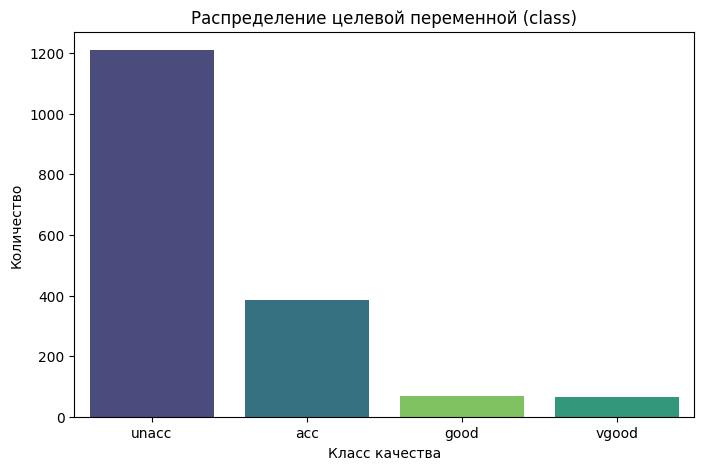

In [3]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='class', order=['unacc', 'acc', 'good', 'vgood'], palette='viridis', hue='class')
plt.title("Распределение целевой переменной (class)")
plt.xlabel("Класс качества")
plt.ylabel("Количество")
plt.show()

Можно заметить, что целевая переменная сильно несбалансирована: большая часть автомобилей из датасета является неприемлимыми, а хороших и очень хороших автомобилей крайне мало

Рассмотрим влияние каждой фичи на класс автомобиля

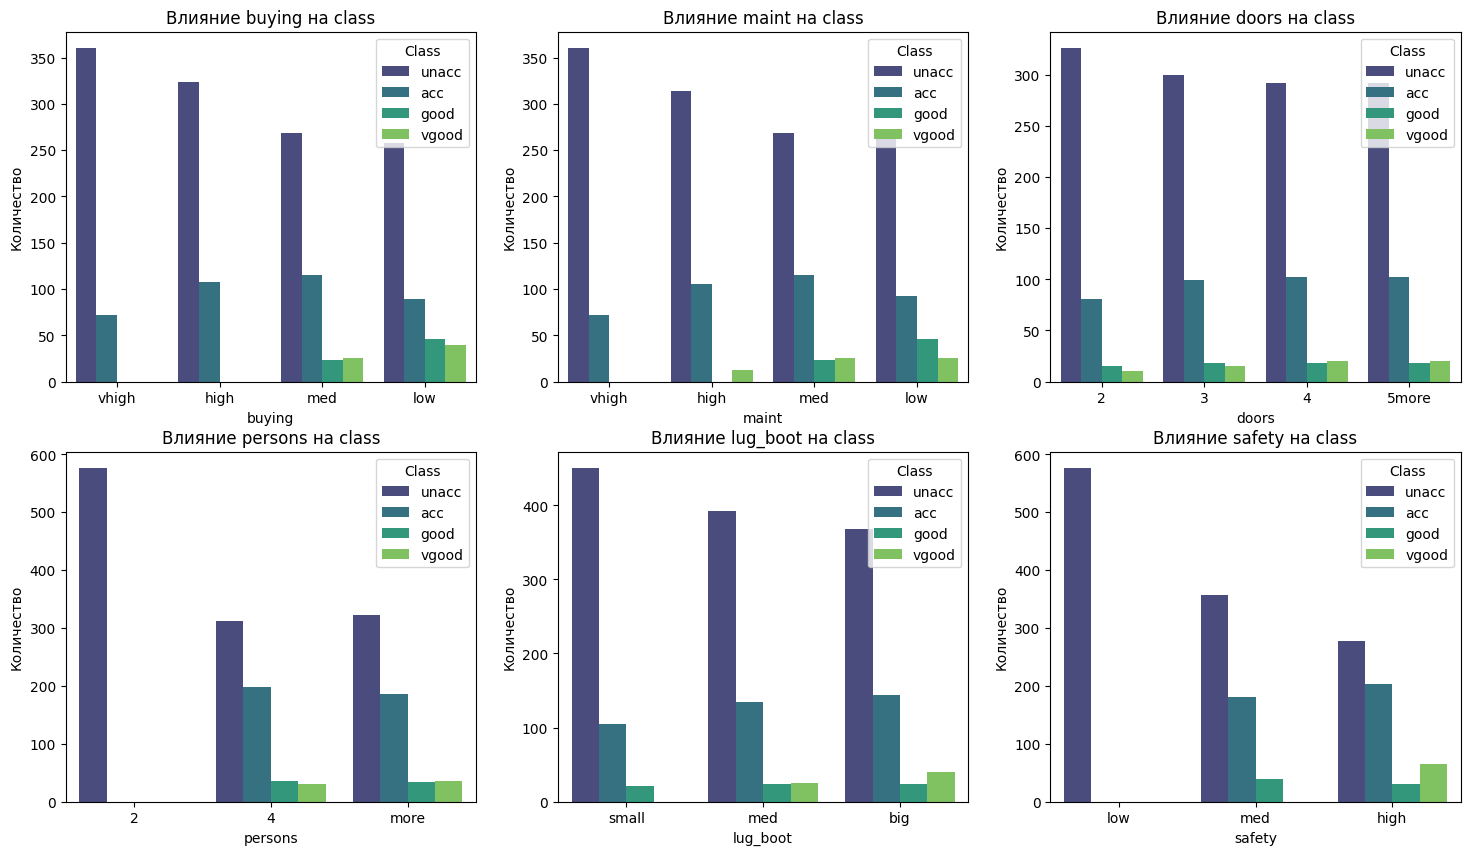

In [4]:
features = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.countplot(data=df, x=feature, hue='class', ax=axes[i], palette='viridis', 
                  hue_order=['unacc', 'acc', 'good', 'vgood'])
    axes[i].set_title(f"Влияние {feature} на class")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Количество")
    axes[i].legend(title='Class', loc='upper right')

plt.show()

Довольно большое влияние на целевую переменную оказывает `safety`: если безопасность в машине низкая, то автомобиль однозначно будет неприемлемой. Аналогичная ситуация и с `persons`: если мест в машине всего 2, то она также будет считаться неприемлемой

Самое слабое влияние на класс оказывает `doors`: хотя чем больше дверей, тем меньше неприемлемых машин, разница довольно мала

## Построение baseline-модели и выбор методов

В качестве baseline модели возьмем простое дерево

Для начала нужно закодировать все признаки и целевую переменную. Лучше сделать это вручную для сохранения порядка значений признаков

In [5]:
mapping = {
    'buying': {'low': 1, 'med': 2, 'high': 3, 'vhigh': 4},
    'maint': {'low': 1, 'med': 2, 'high': 3, 'vhigh': 4},
    'doors': {'2': 2, '3': 3, '4': 4, '5more': 5},
    'persons': {'2': 2, '4': 4, 'more': 5},
    'lug_boot': {'small': 1, 'med': 2, 'big': 3},
    'safety': {'low': 1, 'med': 2, 'high': 3},
    'class': {'unacc': 0, 'acc': 1, 'good': 2, 'vgood': 3}
}

df_encoded = df.replace(mapping)
df_encoded = df_encoded.astype(int)
df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   buying    1728 non-null   int64
 1   maint     1728 non-null   int64
 2   doors     1728 non-null   int64
 3   persons   1728 non-null   int64
 4   lug_boot  1728 non-null   int64
 5   safety    1728 non-null   int64
 6   class     1728 non-null   int64
dtypes: int64(7)
memory usage: 94.6 KB


Разделим датасет на обучающую и тестовую выборки

In [6]:
from sklearn.model_selection import train_test_split

X_encoded = df_encoded.drop(labels=['class'], axis=1)
y_encoded = df_encoded['class']

X_train_encoded, X_test_encoded, y_train_encoded, y_test_encoded = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

Далее подберём гиперпараметры с помощью optuna

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import optuna

def objective_dtc(trial):
    param = {
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy', 'log_loss']),
        'max_depth': trial.suggest_int('max_depth', 2, 32, log=True),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
    }
    
    model = DecisionTreeClassifier(**param, random_state=42, class_weight='balanced')
    score = cross_val_score(model, X_train_encoded, y_train_encoded, cv=5, scoring='f1_macro', n_jobs=-1)
    
    return score.mean()

In [8]:
study = optuna.create_study(direction='maximize')
study.optimize(objective_dtc, n_trials=50)

print(f"Лучшие параметры: {study.best_params}")
print(f"Лучший F1-score: {study.best_value}")

[I 2026-05-31 22:01:30,598] A new study created in memory with name: no-name-f63b4115-274d-4854-92a0-f40f813a4d73
[I 2026-05-31 22:01:31,900] Trial 0 finished with value: 0.7614532225002759 and parameters: {'criterion': 'entropy', 'max_depth': 26, 'min_samples_split': 17, 'min_samples_leaf': 19}. Best is trial 0 with value: 0.7614532225002759.
[I 2026-05-31 22:01:33,080] Trial 1 finished with value: 0.8359540835153803 and parameters: {'criterion': 'gini', 'max_depth': 9, 'min_samples_split': 2, 'min_samples_leaf': 12}. Best is trial 1 with value: 0.8359540835153803.
[I 2026-05-31 22:01:34,034] Trial 2 finished with value: 0.7873377844164583 and parameters: {'criterion': 'log_loss', 'max_depth': 6, 'min_samples_split': 7, 'min_samples_leaf': 12}. Best is trial 1 with value: 0.8359540835153803.
[I 2026-05-31 22:01:34,059] Trial 3 finished with value: 0.7936562772897408 and parameters: {'criterion': 'entropy', 'max_depth': 19, 'min_samples_split': 6, 'min_samples_leaf': 12}. Best is trial

Лучшие параметры: {'criterion': 'log_loss', 'max_depth': 13, 'min_samples_split': 5, 'min_samples_leaf': 3}
Лучший F1-score: 0.9342090066944289


Напишем функцию, которая будет выводить метрики моделей

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

def print_model_metrics(model, X, y):

  pred = model.predict(X)
  print(f"Classification Report: \n{classification_report(y, pred, target_names=['unacc', 'acc', 'good', 'vgood'], digits=3)}\n")

In [10]:
dt_clf = DecisionTreeClassifier(**study.best_params, random_state=42, class_weight='balanced')
dt_clf.fit(X=X_train_encoded, y=y_train_encoded)
print_model_metrics(dt_clf,  X_test_encoded, y_test_encoded)

Classification Report: 
              precision    recall  f1-score   support

       unacc      0.987     0.971     0.979       242
         acc      0.911     0.935     0.923        77
        good      0.923     0.857     0.889        14
       vgood      0.812     1.000     0.897        13

    accuracy                          0.960       346
   macro avg      0.909     0.941     0.922       346
weighted avg      0.961     0.960     0.960       346




Метрики получились довольно хорошими, однако F1-score хороших и очень хороших автомобилей заметно ниже

Попробуем улучшить метрики использовав модель случайного леса

In [11]:
from sklearn.ensemble import RandomForestClassifier

def objective_rfc(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500, step=50),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'max_depth': trial.suggest_int('max_depth', 3, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 15),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    }
    
    model = RandomForestClassifier(**param, random_state=42, class_weight='balanced')
    score = cross_val_score(model, X_train_encoded, y_train_encoded, cv=5, scoring='f1_macro', n_jobs=-1)
    
    return score.mean()

In [12]:
study = optuna.create_study(direction='maximize')
study.optimize(objective_rfc, n_trials=50)

print(f"Лучшие параметры: {study.best_params}")
print(f"Лучший F1-score: {study.best_value}")

[I 2026-05-31 22:01:35,314] A new study created in memory with name: no-name-0360ee60-abce-4570-bdd4-d1b9e78b1a6c
[I 2026-05-31 22:01:35,451] Trial 0 finished with value: 0.8576257828100242 and parameters: {'n_estimators': 50, 'criterion': 'gini', 'max_depth': 30, 'min_samples_split': 12, 'min_samples_leaf': 8, 'max_features': None}. Best is trial 0 with value: 0.8576257828100242.
[I 2026-05-31 22:01:35,789] Trial 1 finished with value: 0.8516231319141895 and parameters: {'n_estimators': 150, 'criterion': 'gini', 'max_depth': 23, 'min_samples_split': 8, 'min_samples_leaf': 8, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8576257828100242.
[I 2026-05-31 22:01:36,574] Trial 2 finished with value: 0.8747497470339762 and parameters: {'n_estimators': 500, 'criterion': 'entropy', 'max_depth': 18, 'min_samples_split': 9, 'min_samples_leaf': 7, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.8747497470339762.
[I 2026-05-31 22:01:36,691] Trial 3 finished with value: 0.7001551006

Лучшие параметры: {'n_estimators': 150, 'criterion': 'entropy', 'max_depth': 23, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None}
Лучший F1-score: 0.9505600529033474


In [13]:
rf_clf = RandomForestClassifier(**study.best_params, random_state=42, class_weight='balanced')
rf_clf.fit(X=X_train_encoded, y=y_train_encoded)
print_model_metrics(rf_clf,  X_test_encoded, y_test_encoded)

Classification Report: 
              precision    recall  f1-score   support

       unacc      0.996     0.996     0.996       242
         acc      0.961     0.961     0.961        77
        good      0.909     0.714     0.800        14
       vgood      0.812     1.000     0.897        13

    accuracy                          0.977       346
   macro avg      0.920     0.918     0.913       346
weighted avg      0.978     0.977     0.976       346




Модель стала лучше предсказывать класс приемлемых авто, а вот хороших заметно хуже - это также сказалось на макро-усреднённых метриках, которые стали хуже чем у простого дерева

Попробуем улучшить метрики с помощью CatBoost

In [14]:
from catboost import CatBoostClassifier

def objective_cbc(trial):
    param = {
        'iterations': trial.suggest_int('iterations', 100, 1000, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 0.3, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-2, 10.0, log=True),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'verbose': False
    }
    
    model = CatBoostClassifier(**param, random_state=42, auto_class_weights='Balanced')
    
    score = cross_val_score(model, X_train_encoded, y_train_encoded, cv=5, scoring='accuracy')
    
    return score.mean()

In [15]:
study = optuna.create_study(direction='maximize')
study.optimize(objective_cbc, n_trials=50)

print(f"Лучшие параметры: {study.best_params}")
print(f"Лучший F1-score: {study.best_value}")

[I 2026-05-31 22:01:54,290] A new study created in memory with name: no-name-3763328c-3a5a-43fe-9f83-8bfe5780fae8
[I 2026-05-31 22:01:57,025] Trial 0 finished with value: 0.8343012609218856 and parameters: {'iterations': 800, 'learning_rate': 0.000512016092554197, 'depth': 5, 'l2_leaf_reg': 7.7881877994548985, 'border_count': 246}. Best is trial 0 with value: 0.8343012609218856.
[I 2026-05-31 22:01:59,520] Trial 1 finished with value: 0.9884241092450164 and parameters: {'iterations': 800, 'learning_rate': 0.06968849808804126, 'depth': 4, 'l2_leaf_reg': 0.751311638385732, 'border_count': 87}. Best is trial 1 with value: 0.9884241092450164.
[I 2026-05-31 22:02:03,586] Trial 2 finished with value: 0.9891461309056663 and parameters: {'iterations': 700, 'learning_rate': 0.03509782529689291, 'depth': 9, 'l2_leaf_reg': 0.015747032590318812, 'border_count': 188}. Best is trial 2 with value: 0.9891461309056663.
[I 2026-05-31 22:02:04,404] Trial 3 finished with value: 0.9146078585256108 and para

Лучшие параметры: {'iterations': 700, 'learning_rate': 0.2927581663450805, 'depth': 4, 'l2_leaf_reg': 0.01459080059389397, 'border_count': 66}
Лучший F1-score: 0.995654789933553


In [16]:
cb_clf = CatBoostClassifier(**study.best_params, random_state=42, auto_class_weights='Balanced', verbose=False)
cb_clf.fit(X=X_train_encoded, y=y_train_encoded)
print_model_metrics(cb_clf, X_test_encoded, y_test_encoded)

Classification Report: 
              precision    recall  f1-score   support

       unacc      1.000     1.000     1.000       242
         acc      1.000     1.000     1.000        77
        good      1.000     1.000     1.000        14
       vgood      1.000     1.000     1.000        13

    accuracy                          1.000       346
   macro avg      1.000     1.000     1.000       346
weighted avg      1.000     1.000     1.000       346




Метрики модели CatBoost получились наилучшими, что говорит о том, что её можно использовать для оценки качества автомобилей. Сохраним модель для дальнейшего использования

In [17]:
cb_clf.save_model('catboost_model.cbm')